**Re-executed 2026-07-25 under flopscope 0.9.1 (PR150 merged) + whestbench 0.13.0; this notebook documents the #13-era estimator (submission 313687, Sobol active-set fold) — analyzed bytes: `.nb_history_bytes/13_sobol_active_set_fold.py` (= git `7d8416a:examples/13_sobol_active_set_fold.py`), plus for §15 `.nb_history_bytes/estimator_ea49268_era13.py` (= git `ea49268:estimator.py`, the era's root estimator: N=40960 + dead correction).**

Fixes applied on re-run: the era files were deleted from `examples/` at HEAD (commit `01123e7` "cleanup"), so the setup cell now materializes the pinned bytes from git history into `.nb_history_bytes/`; §15's `import estimator` was repointed to the preserved era bytes (repo-root `estimator.py` is now the 318873 submission); every figure is stamped with the exact net sample used (synthetic nets, `local_engine.build_mlp(width=256, depth=32)`, seeds 0–9).

# Error Analysis: Sobol Active-Set Fold Estimator (#313687)

Post-hoc analysis of the best submission to understand:
1. **Bias**: Are we consistently under- or over-estimating?
2. **Error by layer**: Which layers contribute most to MSE?
3. **Error by neuron type**: Dead / kink / always-on — where are errors concentrated?
4. **Magnitude dependence**: Do we do worse on large or small activations?

In [1]:
import sys
import subprocess
from pathlib import Path

REPO_ROOT = Path("/Users/natashastewart/whest-kprop-experiments")
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import flopscope as flops
import flopscope.numpy as fnp
from local_engine import build_mlp, monte_carlo_layer_means

# Era bytes (2026-07-25 re-run): the #13-era files were removed from examples/ in commit
# 01123e7 ("cleanup"), so materialize the exact pinned bytes from git history instead.
HIST = REPO_ROOT / ".nb_history_bytes"
HIST.mkdir(exist_ok=True)
_ERA_FILES = {
    "13_sobol_active_set_fold.py": "7d8416adb5e1de714f4ff61415ae5fa4f688490d:examples/13_sobol_active_set_fold.py",
    "estimator_ea49268_era13.py": "ea49268f1ccd92a394dfa51bdbbffd6c22c640a0:estimator.py",
}
for _fname, _ref in _ERA_FILES.items():
    _pth = HIST / _fname
    if not _pth.exists():
        _pth.write_bytes(subprocess.run(["git", "-C", str(REPO_ROOT), "show", _ref],
                                        capture_output=True, check=True).stdout)
_sl = HIST / "sobol_points.npz"   # the era root estimator resolves the artifact next to itself
if not _sl.exists():
    _sl.symlink_to(REPO_ROOT / "sobol_points.npz")

# Import the estimator (preserved #13 era bytes)
import importlib.util as _ilu
_spec13 = _ilu.spec_from_file_location("era13_sobol_active_set_fold",
                                       str(HIST / "13_sobol_active_set_fold.py"))
mod = _ilu.module_from_spec(_spec13); _spec13.loader.exec_module(mod)
Estimator = mod.Estimator

# Net-sample stamp: every figure states exactly which nets it uses.
FIG_NOTE_ALL = ("nets: 10 synthetic MLPs, local_engine.build_mlp(width=256, depth=32, seed=0..9); "
                "GT = 500k-sample MC")
FIG_NOTE = FIG_NOTE_ALL
_orig_plt_show = plt.show
def _stamped_show(*a, **k):
    for _num in plt.get_fignums():
        plt.figure(_num).text(0.995, 0.002, FIG_NOTE, ha="right", va="bottom",
                              fontsize=6.5, color="#888")
    return _orig_plt_show(*a, **k)
plt.show = _stamped_show
print("estimator loaded from", HIST / "13_sobol_active_set_fold.py")


estimator loaded from /Users/natashastewart/whest-kprop-experiments/.nb_history_bytes/13_sobol_active_set_fold.py


## 1. Generate Ground Truth and Predictions

Run the estimator on multiple MLPs and compare against high-sample MC ground truth (N=500k).

In [2]:
N_MLPS = 10
WIDTH, DEPTH = 256, 32
GT_SAMPLES = 500_000
BUDGET = 272_000_000_000

predictions = []
ground_truths = []

for seed in range(N_MLPS):
    mlp = build_mlp(width=WIDTH, depth=DEPTH, seed=seed)
    
    # Ground truth: high-sample MC
    with flops.BudgetContext(flop_budget=int(1e13), quiet=True):
        gt = monte_carlo_layer_means(mlp, GT_SAMPLES, seed=seed + 1000)
    
    # Estimator prediction
    est = Estimator()
    with flops.BudgetContext(flop_budget=BUDGET, quiet=True):
        pred = est.predict(mlp, BUDGET)
    
    predictions.append(np.asarray(pred))
    ground_truths.append(np.asarray(gt))
    print(f"MLP {seed}: MSE = {np.mean((np.asarray(pred) - np.asarray(gt))**2):.3e}")

predictions = np.array(predictions)   # (N_MLPS, 32, 256)
ground_truths = np.array(ground_truths)
errors = predictions - ground_truths  # positive = overestimate
print(f"\nOverall MSE: {np.mean(errors**2):.3e}")
print(f"Overall mean error (bias): {np.mean(errors):.3e}")
print(f"Overall median error: {np.median(errors):.3e}")

/Users/natashastewart/whest-kprop-experiments/.nb_history_bytes/13_sobol_active_set_fold.py:52: SymmetryLossWarning: Symmetry lost along dims (0, 1): slicing removed all symmetric dim groups. Use as_symmetric() to re-tag if you know the result is symmetric. Suppress with flops.configure(symmetry_warnings=False).
  return fnp.eye(width, dtype=fnp.float32)[:, idx] @ values


MLP 0: MSE = 1.375e-06


MLP 1: MSE = 1.382e-06


MLP 2: MSE = 1.643e-06


MLP 3: MSE = 1.457e-06


...

MLP 5: MSE = 1.180e-06


MLP 6: MSE = 1.494e-06


MLP 7: MSE = 1.218e-06


MLP 8: MSE = 1.412e-06


MLP 9: MSE = 9.068e-07

Overall MSE: 1.405e-06
Overall mean error (bias): -1.502e-05
Overall median error: 3.366e-12


## 2. Bias Analysis: Per-Layer

Is the bias systematic across layers?

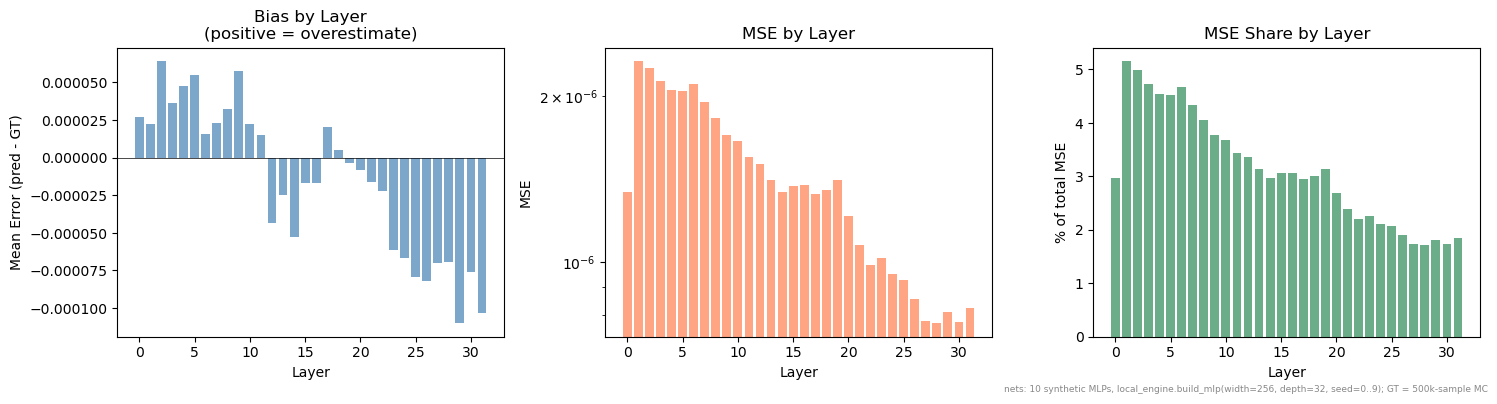

In [3]:
import matplotlib.pyplot as plt

mean_error_by_layer = np.mean(errors, axis=(0, 2))  # avg over MLPs and neurons
std_error_by_layer = np.std(errors, axis=(0, 2))
mse_by_layer = np.mean(errors**2, axis=(0, 2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mean error (bias) by layer
ax = axes[0]
ax.bar(range(DEPTH), mean_error_by_layer, color='steelblue', alpha=0.7)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Layer')
ax.set_ylabel('Mean Error (pred - GT)')
ax.set_title('Bias by Layer\n(positive = overestimate)')

# MSE by layer
ax = axes[1]
ax.bar(range(DEPTH), mse_by_layer, color='coral', alpha=0.7)
ax.set_xlabel('Layer')
ax.set_ylabel('MSE')
ax.set_title('MSE by Layer')
ax.set_yscale('log')

# Fraction of total MSE by layer
ax = axes[2]
frac_mse = mse_by_layer / mse_by_layer.sum()
ax.bar(range(DEPTH), frac_mse * 100, color='seagreen', alpha=0.7)
ax.set_xlabel('Layer')
ax.set_ylabel('% of total MSE')
ax.set_title('MSE Share by Layer')

plt.tight_layout()
plt.show()

## 3. Bias Direction: Over vs Under-estimation

What fraction of neurons are over- vs under-estimated? Does it vary by layer?

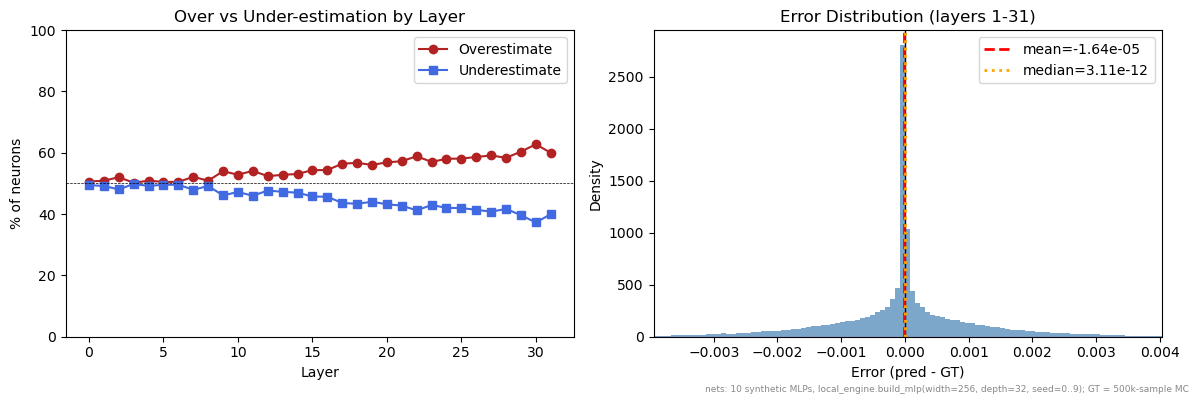

In [4]:
# For each layer, what fraction of (mlp, neuron) pairs are overestimated?
frac_over = np.mean(errors > 0, axis=(0, 2))  # per layer
frac_under = np.mean(errors < 0, axis=(0, 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(range(DEPTH), frac_over * 100, 'o-', label='Overestimate', color='firebrick')
ax.plot(range(DEPTH), frac_under * 100, 's-', label='Underestimate', color='royalblue')
ax.axhline(50, color='k', lw=0.5, ls='--')
ax.set_xlabel('Layer')
ax.set_ylabel('% of neurons')
ax.set_title('Over vs Under-estimation by Layer')
ax.legend()
ax.set_ylim(0, 100)

# Error distribution across all layers (histogram)
ax = axes[1]
flat_errors = errors[:, 1:, :].flatten()  # exclude layer 0 (exact)
ax.hist(flat_errors, bins=200, density=True, alpha=0.7, color='steelblue')
ax.axvline(0, color='k', lw=1)
ax.axvline(np.mean(flat_errors), color='red', lw=2, ls='--', label=f'mean={np.mean(flat_errors):.2e}')
ax.axvline(np.median(flat_errors), color='orange', lw=2, ls=':', label=f'median={np.median(flat_errors):.2e}')
ax.set_xlabel('Error (pred - GT)')
ax.set_ylabel('Density')
ax.set_title('Error Distribution (layers 1-31)')
ax.legend()
ax.set_xlim(np.percentile(flat_errors, 0.5), np.percentile(flat_errors, 99.5))

plt.tight_layout()
plt.show()

## 4. Error by Neuron Type (Dead / Kink / Always-On)

Re-run the analytical classification to label each neuron, then separate MSE by type.

In [5]:
DEAD_THRESH = -2.5
ON_THRESH = 2.5

def classify_neurons(mlp):
    """Return per-layer alpha values and classification masks."""
    width = mlp.width
    alphas_all = []
    types_all = []  # 0=dead, 1=kink, 2=on
    mu_post = np.zeros(width)
    var_post = np.zeros(width)
    
    for layer_idx in range(mlp.depth):
        w = np.asarray(mlp.weights[layer_idx])
        if layer_idx == 0:
            mu_pre = np.zeros(width)
            var_pre = np.sum(w * w, axis=0)
        else:
            mu_pre = w.T @ mu_post
            var_pre = np.sum(w * w * var_post[:, None], axis=0)
        
        var_pre = np.maximum(var_pre, 1e-12)
        sigma_pre = np.sqrt(var_pre)
        alpha = mu_pre / sigma_pre
        
        types = np.ones(width, dtype=int)  # default=kink
        types[alpha < DEAD_THRESH] = 0
        types[alpha > ON_THRESH] = 2
        
        alphas_all.append(alpha)
        types_all.append(types)
        
        # Post-ReLU moments
        from scipy.stats import norm
        phi = norm.pdf(alpha)
        Phi = norm.cdf(alpha)
        mu_post = mu_pre * Phi + sigma_pre * phi
        var_post = (var_pre + mu_pre**2) * Phi + mu_pre * sigma_pre * phi - mu_post**2
        var_post = np.maximum(var_post, 1e-12)
    
    return np.array(alphas_all), np.array(types_all)

# Classify all MLPs
all_alphas = []
all_types = []
for seed in range(N_MLPS):
    mlp = build_mlp(width=WIDTH, depth=DEPTH, seed=seed)
    alpha, types = classify_neurons(mlp)
    all_alphas.append(alpha)
    all_types.append(types)

all_alphas = np.array(all_alphas)  # (N_MLPS, 32, 256)
all_types = np.array(all_types)

print("Neuron type distribution across all MLPs/layers:")
print(f"  Dead  (α < -2.5): {np.mean(all_types == 0)*100:.1f}%")
print(f"  Kink  (-2.5 ≤ α ≤ 2.5): {np.mean(all_types == 1)*100:.1f}%")
print(f"  On    (α > 2.5): {np.mean(all_types == 2)*100:.1f}%")

Neuron type distribution across all MLPs/layers:
  Dead  (α < -2.5): 21.1%
  Kink  (-2.5 ≤ α ≤ 2.5): 57.5%
  On    (α > 2.5): 21.4%


Dead      : MSE=1.542e-08, bias=-9.537e-06, count=17291
Kink      : MSE=1.365e-06, bias=9.887e-06, count=47127
Always-On : MSE=2.884e-06, bias=-8.749e-05, count=17502


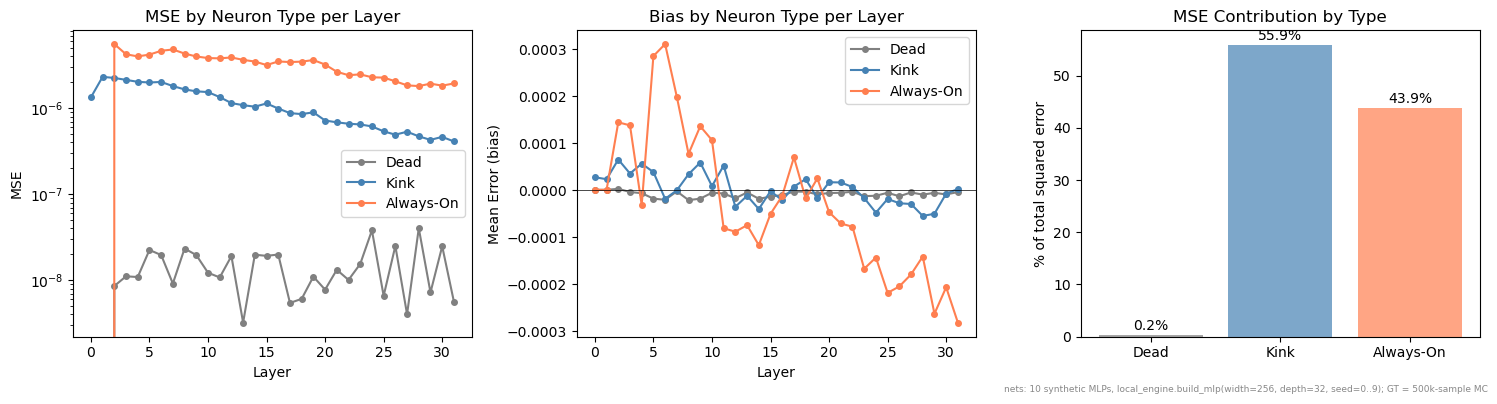

In [6]:
# MSE and bias by neuron type
type_names = ['Dead', 'Kink', 'Always-On']
type_colors = ['gray', 'steelblue', 'coral']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for t, name, color in zip(range(3), type_names, type_colors):
    mask = all_types == t
    type_errors = errors[mask]
    
    mse_t = np.mean(type_errors**2)
    bias_t = np.mean(type_errors)
    print(f"{name:10s}: MSE={mse_t:.3e}, bias={bias_t:.3e}, count={mask.sum()}")

# Per-layer MSE by type
ax = axes[0]
for t, name, color in zip(range(3), type_names, type_colors):
    mse_per_layer = []
    for layer in range(DEPTH):
        mask = all_types[:, layer, :] == t
        if mask.sum() > 0:
            mse_per_layer.append(np.mean(errors[:, layer, :][mask]**2))
        else:
            mse_per_layer.append(0)
    ax.plot(range(DEPTH), mse_per_layer, 'o-', label=name, color=color, markersize=4)
ax.set_xlabel('Layer')
ax.set_ylabel('MSE')
ax.set_title('MSE by Neuron Type per Layer')
ax.set_yscale('log')
ax.legend()

# Per-layer bias by type
ax = axes[1]
for t, name, color in zip(range(3), type_names, type_colors):
    bias_per_layer = []
    for layer in range(DEPTH):
        mask = all_types[:, layer, :] == t
        if mask.sum() > 0:
            bias_per_layer.append(np.mean(errors[:, layer, :][mask]))
        else:
            bias_per_layer.append(0)
    ax.plot(range(DEPTH), bias_per_layer, 'o-', label=name, color=color, markersize=4)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Layer')
ax.set_ylabel('Mean Error (bias)')
ax.set_title('Bias by Neuron Type per Layer')
ax.legend()

# Fraction of total MSE by type
ax = axes[2]
total_mse_contributions = []
for t in range(3):
    mask = all_types == t
    # Weight by count: MSE contribution = sum of squared errors / total count
    total_mse_contributions.append(np.sum(errors[mask]**2))
total = sum(total_mse_contributions)
fracs = [c / total * 100 for c in total_mse_contributions]
ax.bar(type_names, fracs, color=type_colors, alpha=0.7)
ax.set_ylabel('% of total squared error')
ax.set_title('MSE Contribution by Type')
for i, f in enumerate(fracs):
    ax.text(i, f + 1, f'{f:.1f}%', ha='center')

plt.tight_layout()
plt.show()

## 5. Error vs Activation Magnitude

Do we estimate large-magnitude activations worse? Is the relative error constant?

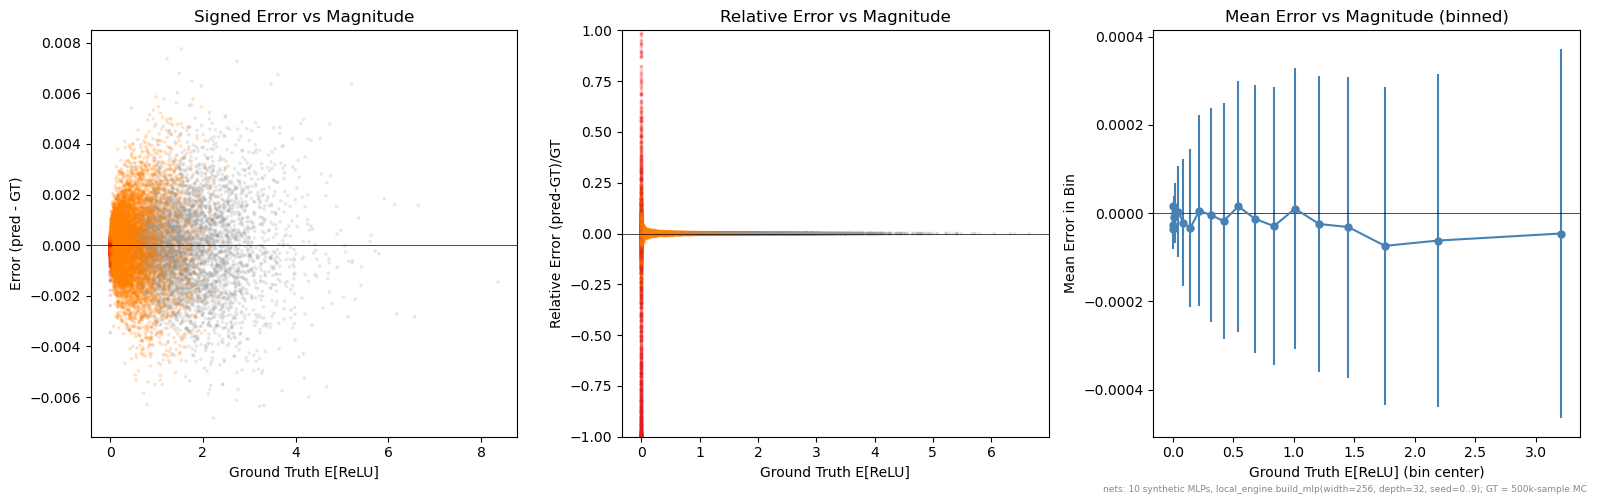

In [7]:
# Scatter: |error| vs ground truth magnitude
# Use a subset to keep plot readable
gt_flat = ground_truths[:, 1:, :].flatten()  # skip layer 0
err_flat = errors[:, 1:, :].flatten()
types_flat = all_types[:, 1:, :].flatten()

# Subsample for plotting
rng = np.random.default_rng(42)
n_plot = 20_000
idx = rng.choice(len(gt_flat), size=min(n_plot, len(gt_flat)), replace=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Signed error vs magnitude
ax = axes[0]
sc = ax.scatter(gt_flat[idx], err_flat[idx], c=types_flat[idx], 
                cmap='Set1', alpha=0.15, s=3, vmin=0, vmax=2)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Ground Truth E[ReLU]')
ax.set_ylabel('Error (pred - GT)')
ax.set_title('Signed Error vs Magnitude')

# Relative error vs magnitude (for non-dead neurons with GT > 0)
ax = axes[1]
live_mask = (gt_flat > 1e-6)
rel_err = err_flat[live_mask] / gt_flat[live_mask]
live_types = types_flat[live_mask]
live_gt = gt_flat[live_mask]

idx2 = rng.choice(len(rel_err), size=min(n_plot, len(rel_err)), replace=False)
sc = ax.scatter(live_gt[idx2], rel_err[idx2], c=live_types[idx2],
                cmap='Set1', alpha=0.15, s=3, vmin=0, vmax=2)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Ground Truth E[ReLU]')
ax.set_ylabel('Relative Error (pred-GT)/GT')
ax.set_title('Relative Error vs Magnitude')
ax.set_ylim(-1, 1)

# Binned mean error by magnitude
ax = axes[2]
gt_nonzero = gt_flat[gt_flat > 1e-6]
err_nonzero = err_flat[gt_flat > 1e-6]
bins = np.percentile(gt_nonzero, np.linspace(0, 100, 21))
bin_centers = []
bin_means = []
bin_stds = []
for i in range(len(bins) - 1):
    mask = (gt_nonzero >= bins[i]) & (gt_nonzero < bins[i+1])
    if mask.sum() > 0:
        bin_centers.append(np.mean(gt_nonzero[mask]))
        bin_means.append(np.mean(err_nonzero[mask]))
        bin_stds.append(np.std(err_nonzero[mask]))

bin_centers = np.array(bin_centers)
bin_means = np.array(bin_means)
bin_stds = np.array(bin_stds)

ax.errorbar(bin_centers, bin_means, yerr=bin_stds/5, fmt='o-', color='steelblue', markersize=5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Ground Truth E[ReLU] (bin center)')
ax.set_ylabel('Mean Error in Bin')
ax.set_title('Mean Error vs Magnitude (binned)')

plt.tight_layout()
plt.show()

## 6. Fold Layers (30-31) Analysis

The fold at layers 30–31 is the most complex part. Are those layers worse?

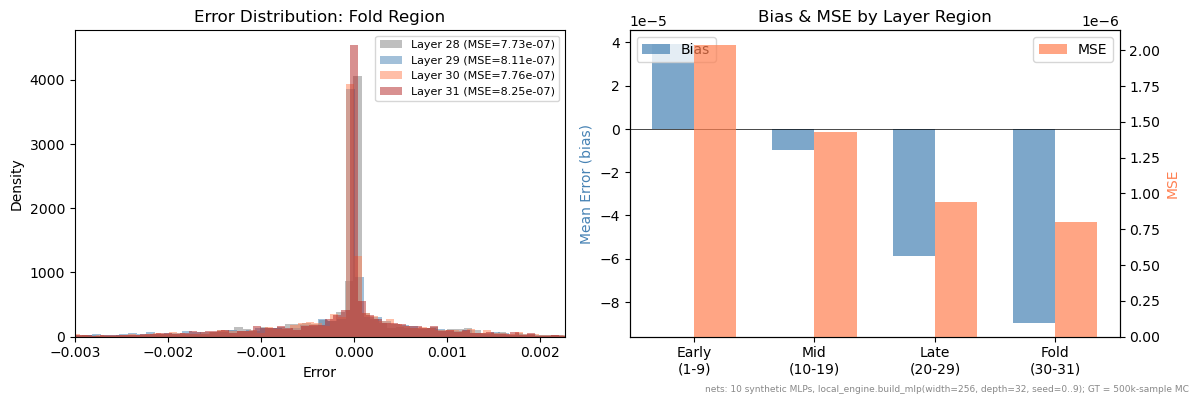

In [8]:
# Compare layers 28-31 error characteristics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

focus_layers = [28, 29, 30, 31]
colors_focus = ['gray', 'steelblue', 'coral', 'firebrick']

ax = axes[0]
for layer, color in zip(focus_layers, colors_focus):
    layer_errors = errors[:, layer, :].flatten()
    ax.hist(layer_errors, bins=100, density=True, alpha=0.5, 
            label=f'Layer {layer} (MSE={np.mean(layer_errors**2):.2e})', color=color)
ax.set_xlabel('Error')
ax.set_ylabel('Density')
ax.set_title('Error Distribution: Fold Region')
ax.legend(fontsize=8)
ax.set_xlim(np.percentile(errors[:, 28:, :].flatten(), 1),
            np.percentile(errors[:, 28:, :].flatten(), 99))

# Bias in fold layers vs non-fold
ax = axes[1]
fold_bias = np.mean(errors[:, 30:32, :], axis=(0, 2))
nonfold_bias_early = np.mean(errors[:, 1:10, :], axis=(0, 2))
nonfold_bias_mid = np.mean(errors[:, 10:20, :], axis=(0, 2))
nonfold_bias_late = np.mean(errors[:, 20:30, :], axis=(0, 2))

regions = ['Early\n(1-9)', 'Mid\n(10-19)', 'Late\n(20-29)', 'Fold\n(30-31)']
biases = [
    np.mean(errors[:, 1:10, :]),
    np.mean(errors[:, 10:20, :]),
    np.mean(errors[:, 20:30, :]),
    np.mean(errors[:, 30:32, :])
]
mses = [
    np.mean(errors[:, 1:10, :]**2),
    np.mean(errors[:, 10:20, :]**2),
    np.mean(errors[:, 20:30, :]**2),
    np.mean(errors[:, 30:32, :]**2)
]

x = np.arange(len(regions))
width_bar = 0.35
ax2 = ax.twinx()
ax.bar(x - width_bar/2, biases, width_bar, color='steelblue', alpha=0.7, label='Bias')
ax2.bar(x + width_bar/2, mses, width_bar, color='coral', alpha=0.7, label='MSE')
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel('Mean Error (bias)', color='steelblue')
ax2.set_ylabel('MSE', color='coral')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Bias & MSE by Layer Region')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 7. Error Correlation Across Layers

If we overestimate at layer L, do we also overestimate at layer L+1?  
This tells us whether errors accumulate (propagation bias) or are independent.

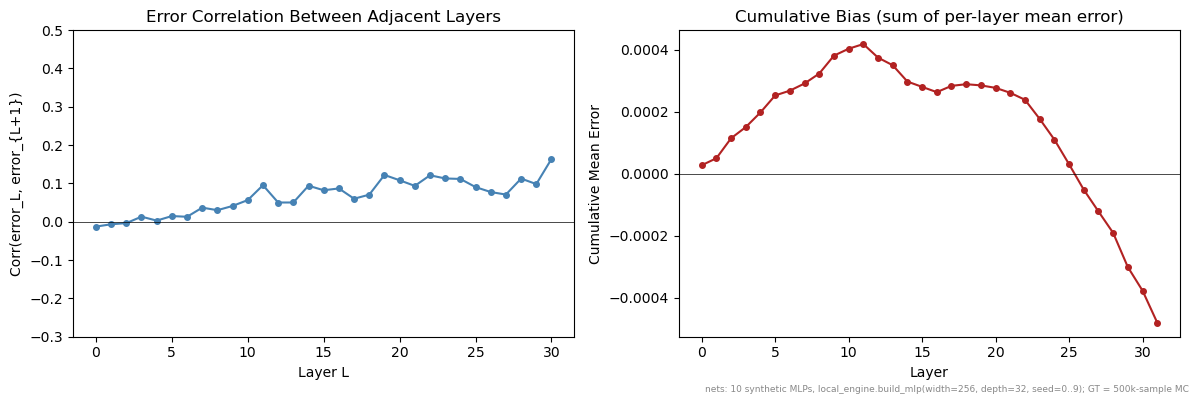

In [9]:
# Per-neuron mean error across MLPs, then correlate across layers
# Use MLP-averaged errors: shape (32, 256)
mean_errors_per_neuron = np.mean(errors, axis=0)  # average over MLPs

# Autocorrelation of error across consecutive layers
layer_corrs = []
for l in range(DEPTH - 1):
    c = np.corrcoef(errors[:, l, :].flatten(), errors[:, l+1, :].flatten())[0, 1]
    layer_corrs.append(c)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(range(DEPTH-1), layer_corrs, 'o-', color='steelblue', markersize=4)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Layer L')
ax.set_ylabel('Corr(error_L, error_{L+1})')
ax.set_title('Error Correlation Between Adjacent Layers')
ax.set_ylim(-0.3, 0.5)

# Error accumulation: does total signed error grow with depth?
ax = axes[1]
cumulative_bias = np.cumsum(np.mean(errors, axis=(0, 2)))  # cumulative bias over layers
ax.plot(range(DEPTH), cumulative_bias, 'o-', color='firebrick', markersize=4)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Layer')
ax.set_ylabel('Cumulative Mean Error')
ax.set_title('Cumulative Bias (sum of per-layer mean error)')

plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [10]:
print("="*60)
print("ERROR ANALYSIS SUMMARY")
print("="*60)
print(f"\nOverall MSE:         {np.mean(errors**2):.3e}")
print(f"Overall bias:        {np.mean(errors):.3e}")
print(f"Overall |bias|/RMSE: {abs(np.mean(errors))/np.sqrt(np.mean(errors**2)):.3f}")
print(f"  → {'Bias-dominated' if abs(np.mean(errors))/np.sqrt(np.mean(errors**2)) > 0.1 else 'Variance-dominated'} error")
print(f"\nFraction overestimated: {np.mean(errors > 0)*100:.1f}%")
print(f"Fraction underestimated: {np.mean(errors < 0)*100:.1f}%")
print(f"\nLayer 0 MSE (exact formula): {np.mean(errors[:, 0, :]**2):.3e}")
print(f"Layers 1-29 MSE:             {np.mean(errors[:, 1:30, :]**2):.3e}")
print(f"Layers 30-31 MSE (fold):     {np.mean(errors[:, 30:32, :]**2):.3e}")
print(f"\nWorst layer: {np.argmax(mse_by_layer)} (MSE={np.max(mse_by_layer):.3e})")
print(f"Best layer:  {np.argmin(mse_by_layer)} (MSE={np.min(mse_by_layer):.3e})")
print(f"\n--- By neuron type ---")
for t, name in enumerate(type_names):
    mask = all_types == t
    if mask.sum() > 0:
        t_err = errors[mask]
        print(f"  {name:10s}: MSE={np.mean(t_err**2):.3e}, bias={np.mean(t_err):+.3e}, n={mask.sum()}")
print("\n" + "="*60)

ERROR ANALYSIS SUMMARY

Overall MSE:         1.405e-06
Overall bias:        -1.502e-05
Overall |bias|/RMSE: 0.013
  → Variance-dominated error

Fraction overestimated: 55.0%
Fraction underestimated: 45.0%

Layer 0 MSE (exact formula): 1.336e-06
Layers 1-29 MSE:             1.449e-06
Layers 30-31 MSE (fold):     8.007e-07

Worst layer: 1 (MSE=2.316e-06)
Best layer:  28 (MSE=7.732e-07)

--- By neuron type ---
  Dead      : MSE=1.542e-08, bias=-9.537e-06, n=17291
  Kink      : MSE=1.365e-06, bias=+9.887e-06, n=47127
  Always-On : MSE=2.884e-06, bias=-8.749e-05, n=17502



## 9. Hypothesis: Heavy-Tail Underestimation

**Claim**: Post-ReLU activations follow a mixture of normal + log-normal. Pure MC (N=16384)
underestimates the heavy tail → systematic negative bias.

**Test**: Forward-pass a single MLP, extract raw per-sample activations at a mid/late layer,
fit Normal + LogNormal mixture via EM, and compare E[ReLU] from:
- (a) MC sample mean (what our estimator does)
- (b) MLE mixture analytical E[ReLU]
- (c) Ground truth (500k MC)

In [11]:
# Single-net section (§9): figures below use ONE synthetic net (seed 0), not the 10-net sample.
FIG_NOTE = ("net: single synthetic MLP, build_mlp(width=256, depth=32, seed=0); MC n=16,384 vs reference n=200,000 (rng seed 42)")

from scipy.stats import norm as sp_norm, lognorm
from scipy.optimize import minimize

# Forward pass ONE MLP, collecting per-sample post-ReLU activations at selected layers
mlp0 = build_mlp(width=WIDTH, depth=DEPTH, seed=0)

# Use numpy (not flopscope) for direct MC — we want raw sample arrays
rng_mc = np.random.default_rng(42)
n_mc = 16384  # same as our estimator
x_mc = rng_mc.standard_normal((n_mc, WIDTH)).astype(np.float32)

# Also run a large reference (200k samples)
x_ref = rng_mc.standard_normal((200_000, WIDTH)).astype(np.float32)

# Forward both through numpy
post_relu_16k = []  # per-layer: (16384, 256) 
post_relu_ref = []

x_small = x_mc.copy()
x_large = x_ref.copy()
for layer_idx in range(DEPTH):
    w = np.asarray(mlp0.weights[layer_idx])
    x_small = np.maximum(x_small @ w, 0.0)
    x_large = np.maximum(x_large @ w, 0.0)
    post_relu_16k.append(x_small.copy())
    post_relu_ref.append(x_large.copy())

print("Forward pass done. Shapes:", post_relu_16k[0].shape, post_relu_ref[0].shape)

Forward pass done. Shapes: (16384, 256) (200000, 256)


In [12]:
# Check distribution shape at a few layers for "kink" neurons
# Pick layers 10, 20, 30 and a few kink neurons in each
import pandas as pd

def fit_normal_lognormal_mixture(samples):
    """EM fit of a mixture: π·Normal(μ,σ²) + (1-π)·LogNormal(μ_ln, σ_ln²).
    
    Only uses positive samples for the log-normal component.
    Returns (π, μ_n, σ_n, μ_ln, σ_ln).
    """
    pos = samples[samples > 0]
    if len(pos) < 10:
        return None
    
    n = len(samples)
    n_pos = len(pos)
    
    # Initialize
    pi = 0.5
    mu_n = np.mean(samples)
    sigma_n = np.std(samples) + 1e-10
    log_pos = np.log(pos + 1e-30)
    mu_ln = np.mean(log_pos)
    sigma_ln = np.std(log_pos) + 1e-10
    
    # EM iterations
    for _ in range(100):
        # E-step: responsibilities for positive samples
        p_norm = sp_norm.pdf(pos, mu_n, sigma_n) * pi
        p_ln = lognorm.pdf(pos, s=sigma_ln, scale=np.exp(mu_ln)) * (1 - pi)
        
        total = p_norm + p_ln + 1e-300
        gamma_norm = p_norm / total
        gamma_ln = p_ln / total
        
        n_zero = n - n_pos
        
        # M-step
        w_norm_pos = gamma_norm.sum()
        w_norm_total = w_norm_pos + n_zero
        
        mu_n_new = (np.sum(gamma_norm * pos) + np.sum(samples[samples <= 0])) / (w_norm_total + 1e-10)
        sigma_n_new = np.sqrt(
            (np.sum(gamma_norm * (pos - mu_n_new)**2) + 
             np.sum((samples[samples <= 0] - mu_n_new)**2)) / (w_norm_total + 1e-10)
        ) + 1e-10
        
        w_ln = gamma_ln.sum()
        if w_ln > 1e-6:
            mu_ln_new = np.sum(gamma_ln * log_pos) / w_ln
            sigma_ln_new = np.sqrt(np.sum(gamma_ln * (log_pos - mu_ln_new)**2) / w_ln) + 1e-10
        else:
            mu_ln_new, sigma_ln_new = mu_ln, sigma_ln
        
        pi_new = w_norm_total / n
        
        if abs(pi_new - pi) < 1e-6:
            break
        
        pi, mu_n, sigma_n, mu_ln, sigma_ln = pi_new, mu_n_new, sigma_n_new, mu_ln_new, sigma_ln_new
    
    return pi, mu_n, sigma_n, mu_ln, sigma_ln


def mixture_expected_relu(pi, mu_n, sigma_n, mu_ln, sigma_ln):
    """Analytical E[ReLU(x)] for Normal+LogNormal mixture.
    
    E[ReLU(x)] = π·E[max(Normal,0)] + (1-π)·E[max(LogNormal,0)]
    For Normal(μ,σ²): E[max(x,0)] = μΦ(μ/σ) + σφ(μ/σ)
    For LogNormal: E[max(x,0)] = E[x] = exp(μ_ln + σ_ln²/2) (always positive)
    """
    alpha = mu_n / sigma_n
    e_relu_norm = mu_n * sp_norm.cdf(alpha) + sigma_n * sp_norm.pdf(alpha)
    e_relu_ln = np.exp(mu_ln + sigma_ln**2 / 2)
    return pi * e_relu_norm + (1 - pi) * e_relu_ln


# Test on selected layers and neurons
test_layers = [5, 10, 15, 20, 25, 30]
results = []

for layer in test_layers:
    types_l = all_types[0, layer, :]
    kink_neurons = np.where(types_l == 1)[0][:20]
    on_neurons = np.where(types_l == 2)[0][:10]
    
    for neuron_idx in np.concatenate([kink_neurons, on_neurons]):
        samples_16k = post_relu_16k[layer][:, neuron_idx]
        samples_ref = post_relu_ref[layer][:, neuron_idx]
        
        mc_est = np.mean(samples_16k)
        gt_est = np.mean(samples_ref)
        
        fit = fit_normal_lognormal_mixture(samples_16k)
        if fit is not None:
            pi, mu_n, sigma_n, mu_ln, sigma_ln = fit
            mix_est = mixture_expected_relu(pi, mu_n, sigma_n, mu_ln, sigma_ln)
        else:
            mix_est = mc_est
            pi = 1.0
        
        neuron_type = 'kink' if types_l[neuron_idx] == 1 else 'on'
        results.append({
            'layer': layer, 'neuron': neuron_idx, 'type': neuron_type,
            'mc_16k': mc_est, 'mixture_mle': mix_est, 'gt_200k': gt_est,
            'pi_normal': pi,
            'err_mc': mc_est - gt_est,
            'err_mix': mix_est - gt_est,
        })

results_df = pd.DataFrame(results)
print(f"Fitted {len(results_df)} neurons across {len(test_layers)} layers")
print(f"\nMean errors:")
print(f"  MC 16k:    {results_df['err_mc'].mean():.6e} (bias)")
print(f"  Mixture:   {results_df['err_mix'].mean():.6e} (bias)")
print(f"\nMSE:")
print(f"  MC 16k:    {(results_df['err_mc']**2).mean():.6e}")
print(f"  Mixture:   {(results_df['err_mix']**2).mean():.6e}")
print(f"\nMixture better? {(results_df['err_mix']**2).mean() < (results_df['err_mc']**2).mean()}")

Fitted 180 neurons across 6 layers

Mean errors:
  MC 16k:    1.133306e-04 (bias)
  Mixture:   1.654183e-02 (bias)

MSE:
  MC 16k:    1.037756e-05
  Mixture:   1.129105e-03

Mixture better? False


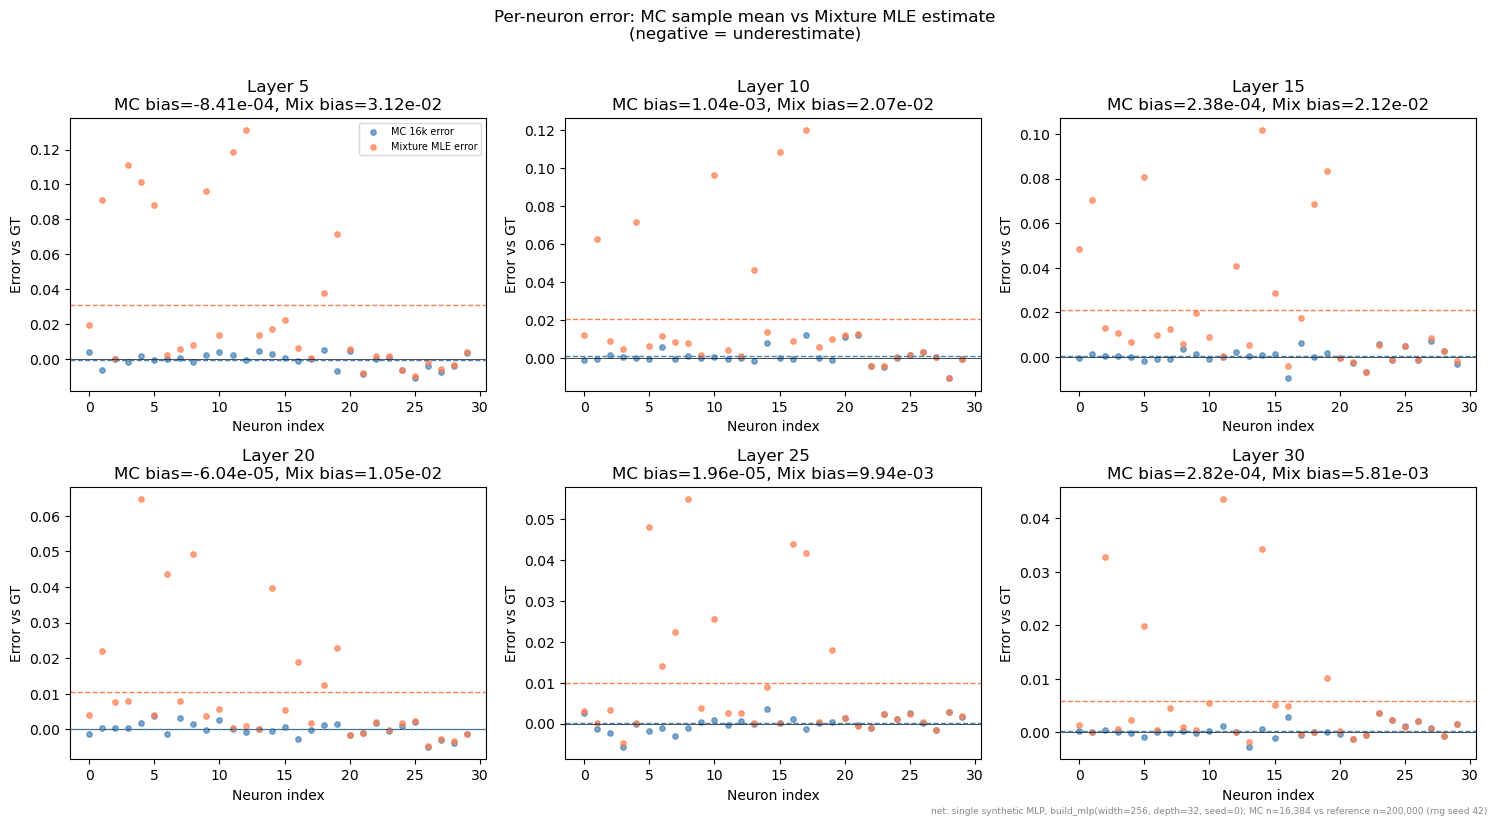


--- By neuron type ---

KINK neurons (n=120):
  MC bias:      3.0321e-04
  Mixture bias: 2.4763e-02
  MC MSE:       6.3664e-06
  Mixture MSE:  1.6848e-03
  Avg π_normal: 0.677

ON neurons (n=60):
  MC bias:      -2.6642e-04
  Mixture bias: 9.9586e-05
  MC MSE:       1.8400e-05
  Mixture MSE:  1.7617e-05
  Avg π_normal: 0.519


In [13]:
# Visualize: per-layer comparison MC vs Mixture vs GT
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, layer in enumerate(test_layers):
    ax = axes[i // 3, i % 3]
    layer_df = results_df[results_df['layer'] == layer]
    
    x_ax = np.arange(len(layer_df))
    ax.scatter(x_ax, layer_df['err_mc'], s=15, alpha=0.7, label='MC 16k error', color='steelblue')
    ax.scatter(x_ax, layer_df['err_mix'], s=15, alpha=0.7, label='Mixture MLE error', color='coral')
    ax.axhline(0, color='k', lw=0.5)
    ax.axhline(layer_df['err_mc'].mean(), color='steelblue', ls='--', lw=1)
    ax.axhline(layer_df['err_mix'].mean(), color='coral', ls='--', lw=1)
    ax.set_title(f'Layer {layer}\nMC bias={layer_df["err_mc"].mean():.2e}, Mix bias={layer_df["err_mix"].mean():.2e}')
    ax.set_xlabel('Neuron index')
    ax.set_ylabel('Error vs GT')
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle('Per-neuron error: MC sample mean vs Mixture MLE estimate\n(negative = underestimate)', y=1.01)
plt.tight_layout()
plt.show()

# Summary by type
print("\n--- By neuron type ---")
for t in ['kink', 'on']:
    sub = results_df[results_df['type'] == t]
    print(f"\n{t.upper()} neurons (n={len(sub)}):")
    print(f"  MC bias:      {sub['err_mc'].mean():.4e}")
    print(f"  Mixture bias: {sub['err_mix'].mean():.4e}")
    print(f"  MC MSE:       {(sub['err_mc']**2).mean():.4e}")
    print(f"  Mixture MSE:  {(sub['err_mix']**2).mean():.4e}")
    print(f"  Avg π_normal: {sub['pi_normal'].mean():.3f}")

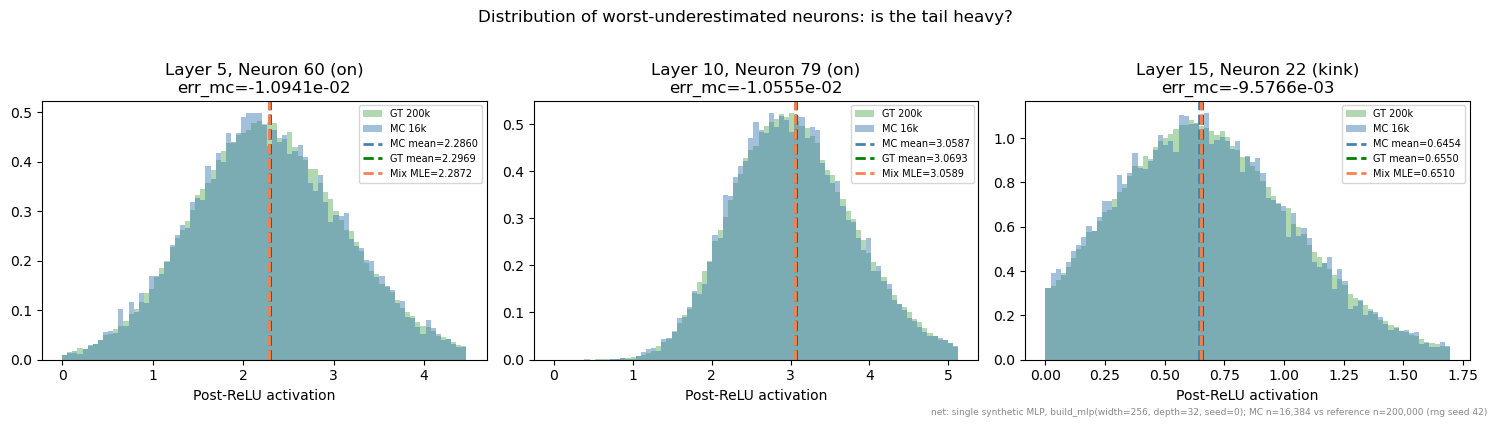


Excess kurtosis of post-ReLU activations by layer:


  Layer  5: mean kurtosis = 1.33 (normal=0, heavy-tail>0)


  Layer 10: mean kurtosis = 1.35 (normal=0, heavy-tail>0)


  Layer 15: mean kurtosis = 1.30 (normal=0, heavy-tail>0)


  Layer 20: mean kurtosis = 1.42 (normal=0, heavy-tail>0)


  Layer 25: mean kurtosis = 1.09 (normal=0, heavy-tail>0)


  Layer 30: mean kurtosis = 1.16 (normal=0, heavy-tail>0)


In [14]:
# Key diagnostic: look at the actual distribution shape
# Pick 3 neurons where MC underestimates the most
worst_under = results_df.nsmallest(3, 'err_mc')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (_, row) in enumerate(worst_under.iterrows()):
    ax = axes[i]
    layer, neuron = int(row['layer']), int(row['neuron'])
    
    samples = post_relu_16k[layer][:, neuron]
    samples_large = post_relu_ref[layer][:, neuron]
    
    # Histogram
    pos_samples = samples[samples > 0]
    pos_large = samples_large[samples_large > 0]
    
    bins_h = np.linspace(0, np.percentile(pos_large, 99), 80)
    ax.hist(pos_large, bins=bins_h, density=True, alpha=0.3, color='green', label=f'GT 200k')
    ax.hist(pos_samples, bins=bins_h, density=True, alpha=0.5, color='steelblue', label=f'MC 16k')
    
    # Mark means
    ax.axvline(np.mean(samples), color='steelblue', ls='--', lw=2, label=f'MC mean={np.mean(samples):.4f}')
    ax.axvline(np.mean(samples_large), color='green', ls='--', lw=2, label=f'GT mean={np.mean(samples_large):.4f}')
    ax.axvline(row['mixture_mle'], color='coral', ls='--', lw=2, label=f'Mix MLE={row["mixture_mle"]:.4f}')
    
    ax.set_title(f'Layer {layer}, Neuron {neuron} ({row["type"]})\nerr_mc={row["err_mc"]:.4e}')
    ax.legend(fontsize=7)
    ax.set_xlabel('Post-ReLU activation')

plt.suptitle('Distribution of worst-underestimated neurons: is the tail heavy?', y=1.02)
plt.tight_layout()
plt.show()

# Quantify tail heaviness: kurtosis
from scipy.stats import kurtosis
print("\nExcess kurtosis of post-ReLU activations by layer:")
for layer in test_layers:
    pos_vals = post_relu_ref[layer][post_relu_ref[layer] > 0]
    # Per-neuron kurtosis (average)
    kurts = [kurtosis(post_relu_ref[layer][:, j][post_relu_ref[layer][:, j] > 0]) 
             for j in range(WIDTH) if (post_relu_ref[layer][:, j] > 0).sum() > 100]
    print(f"  Layer {layer:2d}: mean kurtosis = {np.mean(kurts):.2f} (normal=0, heavy-tail>0)")

## 10. Fix 1: Analytical Correction for Dead Neurons

Dead neurons (α < -2.5) are predicted as 0, but the true E[ReLU(z)] = μΦ(α) + σφ(α) > 0.
We already have μ, σ, α from classification — just add the correction. Zero extra FLOPs.

In [15]:
FIG_NOTE = FIG_NOTE_ALL   # back to the 10-net sample from here on

from scipy.stats import norm as sp_norm_fix

# Compute the analytical correction for dead neurons using our classification data
# all_alphas: (N_MLPS, 32, 256), all_types: (N_MLPS, 32, 256)

def compute_dead_correction(alphas, types, mlp_weights_list):
    """For each dead neuron, compute E[ReLU(z)] = μΦ(α) + σφ(α) instead of 0.
    
    Returns correction array same shape as predictions: (N_MLPS, 32, 256)
    """
    corrections = np.zeros_like(alphas)
    
    for mlp_idx in range(alphas.shape[0]):
        mu_post = np.zeros(WIDTH)
        var_post = np.zeros(WIDTH)
        
        for layer_idx in range(DEPTH):
            w = np.asarray(mlp_weights_list[mlp_idx][layer_idx])
            if layer_idx == 0:
                mu_pre = np.zeros(WIDTH)
                var_pre = np.sum(w * w, axis=0)
            else:
                mu_pre = w.T @ mu_post
                var_pre = np.sum(w * w * var_post[:, None], axis=0)
            
            var_pre = np.maximum(var_pre, 1e-12)
            sigma_pre = np.sqrt(var_pre)
            alpha = mu_pre / sigma_pre
            
            # Dead neurons: add E[ReLU] correction
            dead_mask = alpha < DEAD_THRESH
            if np.any(dead_mask):
                phi_val = sp_norm_fix.pdf(alpha[dead_mask])
                Phi_val = sp_norm_fix.cdf(alpha[dead_mask])
                e_relu = mu_pre[dead_mask] * Phi_val + sigma_pre[dead_mask] * phi_val
                corrections[mlp_idx, layer_idx, dead_mask] = e_relu
            
            # Propagate moments (same as estimator)
            phi = sp_norm_fix.pdf(alpha)
            Phi = sp_norm_fix.cdf(alpha)
            mu_post = mu_pre * Phi + sigma_pre * phi
            var_post = (var_pre + mu_pre**2) * Phi + mu_pre * sigma_pre * phi - mu_post**2
            var_post = np.maximum(var_post, 1e-12)
    
    return corrections

# Build all MLPs and compute corrections
mlp_weights_list = []
for seed in range(N_MLPS):
    mlp_tmp = build_mlp(width=WIDTH, depth=DEPTH, seed=seed)
    mlp_weights_list.append(mlp_tmp.weights)

dead_corrections = compute_dead_correction(all_alphas, all_types, mlp_weights_list)

# Apply correction: new_predictions = predictions + dead_corrections (add back the missing E[ReLU])
predictions_fix1 = predictions + dead_corrections
errors_fix1 = predictions_fix1 - ground_truths

print("=== Fix 1: Dead-Neuron Analytical Correction ===")
print(f"\nBefore (original estimator):")
print(f"  MSE:  {np.mean(errors**2):.6e}")
print(f"  Bias: {np.mean(errors):.6e}")
print(f"  |bias|/RMSE: {abs(np.mean(errors))/np.sqrt(np.mean(errors**2)):.4f}")
print(f"\nAfter (with dead correction):")
print(f"  MSE:  {np.mean(errors_fix1**2):.6e}")
print(f"  Bias: {np.mean(errors_fix1):.6e}")
print(f"  |bias|/RMSE: {abs(np.mean(errors_fix1))/np.sqrt(np.mean(errors_fix1**2)):.4f}")
print(f"\nMSE change: {(np.mean(errors_fix1**2) - np.mean(errors**2))/np.mean(errors**2)*100:+.2f}%")
print(f"Bias change: {np.mean(errors_fix1) - np.mean(errors):+.6e}")

# How much correction was added?
print(f"\nMean dead-neuron correction per neuron: {dead_corrections[all_types == 0].mean():.6e}")
print(f"Max correction: {dead_corrections.max():.6e}")
print(f"Total dead neurons corrected: {(all_types == 0).sum()}")

=== Fix 1: Dead-Neuron Analytical Correction ===

Before (original estimator):
  MSE:  1.404697e-06
  Bias: -1.501780e-05
  |bias|/RMSE: 0.0127

After (with dead correction):
  MSE:  1.414413e-06
  Bias: 2.532418e-06
  |bias|/RMSE: 0.0021

MSE change: +0.69%
Bias change: +1.755022e-05

Mean dead-neuron correction per neuron: 8.314811e-05
Max correction: 1.945585e-03
Total dead neurons corrected: 17291


## 11. Fix 2: Analytical Correction for Always-On Neurons (Fold)

For on-neurons at the fold (layer 30), we use E[z] = W^T @ mean_prev.
The true value is E[ReLU(z)] = μΦ(α) + σφ(α), which is slightly larger.
The difference: σφ(α) - μΦ(-α). For α=2.5 this is ~0.002σ per neuron.

In [16]:
# Fix 2: For always-on neurons, the estimator approximates E[ReLU(z)] ≈ E[z] = μ.
# True: E[ReLU(z)] = μΦ(α) + σφ(α). The missed contribution is:
#   E[ReLU] - E[z] = μ(Φ(α) - 1) + σφ(α) = σφ(α) - μΦ(-α)
# This is always positive for α > 0.

def compute_on_correction(alphas, types, mlp_weights_list):
    """For always-on neurons, compute E[ReLU(z)] - E[z] correction."""
    corrections = np.zeros_like(alphas)
    
    for mlp_idx in range(alphas.shape[0]):
        mu_post = np.zeros(WIDTH)
        var_post = np.zeros(WIDTH)
        
        for layer_idx in range(DEPTH):
            w = np.asarray(mlp_weights_list[mlp_idx][layer_idx])
            if layer_idx == 0:
                mu_pre = np.zeros(WIDTH)
                var_pre = np.sum(w * w, axis=0)
            else:
                mu_pre = w.T @ mu_post
                var_pre = np.sum(w * w * var_post[:, None], axis=0)
            
            var_pre = np.maximum(var_pre, 1e-12)
            sigma_pre = np.sqrt(var_pre)
            alpha = mu_pre / sigma_pre
            
            # On neurons: E[ReLU] - E[z] = σφ(α) - μΦ(-α)
            on_mask = alpha > ON_THRESH
            if np.any(on_mask):
                phi_val = sp_norm_fix.pdf(alpha[on_mask])
                Phi_neg = sp_norm_fix.cdf(-alpha[on_mask])
                correction = sigma_pre[on_mask] * phi_val - mu_pre[on_mask] * Phi_neg
                corrections[mlp_idx, layer_idx, on_mask] = correction
            
            # Propagate moments
            phi = sp_norm_fix.pdf(alpha)
            Phi = sp_norm_fix.cdf(alpha)
            mu_post = mu_pre * Phi + sigma_pre * phi
            var_post = (var_pre + mu_pre**2) * Phi + mu_pre * sigma_pre * phi - mu_post**2
            var_post = np.maximum(var_post, 1e-12)
    
    return corrections

on_corrections = compute_on_correction(all_alphas, all_types, mlp_weights_list)

# Note: the on-correction only applies where the estimator uses the analytical
# E[z] approximation. In the current estimator, that's only at the FOLD (layer 30).
# But conceptually, the on-neurons in the MC pass are handled correctly by MC.
# Let's test both: full correction (all layers) and fold-only correction.

# Full on-correction (even though MC handles them in layers 0-29)
predictions_fix2_full = predictions + on_corrections
errors_fix2_full = predictions_fix2_full - ground_truths

# Fold-only (layer 30-31 on-neurons)
on_corrections_fold = np.zeros_like(on_corrections)
on_corrections_fold[:, 30:32, :] = on_corrections[:, 30:32, :]
predictions_fix2_fold = predictions + on_corrections_fold
errors_fix2_fold = predictions_fix2_fold - ground_truths

print("=== Fix 2: Always-On Correction ===")
print(f"\nBefore (original):")
print(f"  MSE:  {np.mean(errors**2):.6e}")
print(f"  Bias: {np.mean(errors):.6e}")
print(f"\nFix 2a — fold-only (layers 30-31):")
print(f"  MSE:  {np.mean(errors_fix2_fold**2):.6e}")
print(f"  Bias: {np.mean(errors_fix2_fold):.6e}")
print(f"  MSE change: {(np.mean(errors_fix2_fold**2) - np.mean(errors**2))/np.mean(errors**2)*100:+.3f}%")
print(f"\nFix 2b — all layers:")
print(f"  MSE:  {np.mean(errors_fix2_full**2):.6e}")
print(f"  Bias: {np.mean(errors_fix2_full):.6e}")
print(f"  MSE change: {(np.mean(errors_fix2_full**2) - np.mean(errors**2))/np.mean(errors**2)*100:+.3f}%")

print(f"\nMean on-neuron correction: {on_corrections[all_types == 2].mean():.6e}")
print(f"Mean correction at fold (layer 30): {on_corrections[:, 30, :][all_types[:, 30, :] == 2].mean():.6e}")

=== Fix 2: Always-On Correction ===

Before (original):
  MSE:  1.404697e-06
  Bias: -1.501780e-05

Fix 2a — fold-only (layers 30-31):
  MSE:  1.404769e-06
  Bias: -1.450194e-05
  MSE change: +0.005%

Fix 2b — all layers:
  MSE:  1.416128e-06
  Bias: 3.455260e-06
  MSE change: +0.814%

Mean on-neuron correction: 8.646515e-05
Mean correction at fold (layer 30): 2.302256e-05


## 12. Fix 3: Tighten Dead Threshold

Use α < -3.5 or -4.0 instead of -2.5 so fewer neurons get pruned (more go through MC).
Tradeoff: larger active set → more FLOPs per layer matmul.

In [17]:
# Fix 3: What if we used a tighter dead threshold?
# Simulate: for neurons with α between old_thresh and new_thresh,
# they would now be in the MC pass instead of being set to 0.
# Their true E[ReLU] would be captured by MC (unbiased).
# Neurons still below new_thresh remain at 0 (or get Fix 1 correction).

# We can't re-run the estimator easily, but we can quantify:
# - How many neurons move from dead→kink with tighter threshold?
# - What's the total missed E[ReLU] for neurons in the gap?

thresholds_to_test = [-2.5, -3.0, -3.5, -4.0, -5.0]

print("=== Fix 3: Tighter Dead Threshold ===\n")
print(f"{'Threshold':>10} | {'Dead %':>7} | {'Kink %':>7} | {'On %':>7} | {'Dead bias contrib':>18} | {'Active set size':>15}")
print("-" * 85)

for thresh in thresholds_to_test:
    # Reclassify
    dead_mask = all_alphas < thresh
    on_mask = all_alphas > ON_THRESH
    kink_mask = ~dead_mask & ~on_mask
    
    # Dead-neuron bias: sum of missed E[ReLU] for neurons still below threshold
    # (neurons that moved to kink are now handled by MC → unbiased)
    remaining_dead_errors = errors[dead_mask]  # original errors for still-dead neurons
    
    # The bias contribution from dead neurons at this threshold
    # = what the estimator predicts (0) minus truth, for neurons still classified dead
    dead_bias = -ground_truths[dead_mask].mean() if dead_mask.sum() > 0 else 0
    
    # Average active set size per layer (kink + on neurons)
    active_per_layer = np.mean(np.sum(~dead_mask, axis=2), axis=0).mean()
    
    print(f"{thresh:>10.1f} | {dead_mask.mean()*100:>6.1f}% | {kink_mask.mean()*100:>6.1f}% | "
          f"{on_mask.mean()*100:>6.1f}% | {dead_bias:>18.6e} | {active_per_layer:>15.1f}")

# Estimate FLOP cost increase from larger active set
print("\n--- FLOP cost estimate ---")
for thresh in thresholds_to_test:
    dead_mask_t = all_alphas < thresh
    active_per_layer = np.mean(np.sum(~dead_mask_t, axis=2), axis=0)
    # MC matmul cost ≈ 2 * N_samples * active_in * active_out per layer
    # Approximate as 2 * 16384 * active^2 per layer (square assumption)
    total_mc_flops = sum(2 * 16384 * active_per_layer[l]**2 for l in range(DEPTH))
    print(f"  α < {thresh:>4.1f}: avg active/layer = {active_per_layer.mean():.0f}, "
          f"est MC FLOPs ≈ {total_mc_flops:.2e} "
          f"({'OK' if total_mc_flops < 272e9 else 'OVER BUDGET'})")

=== Fix 3: Tighter Dead Threshold ===

 Threshold |  Dead % |  Kink % |    On % |  Dead bias contrib | Active set size
-------------------------------------------------------------------------------------
      -2.5 |   21.1% |   57.5% |   21.4% |      -1.047886e-04 |           202.0
      -3.0 |   17.9% |   60.8% |   21.4% |      -2.537818e-05 |           210.3
      -3.5 |   14.9% |   63.7% |   21.4% |      -6.560057e-06 |           217.8
      -4.0 |   12.5% |   66.2% |   21.4% |      -1.578803e-06 |           224.1
      -5.0 |    8.8% |   69.8% |   21.4% |      -1.041977e-07 |           233.4

--- FLOP cost estimate ---
  α < -2.5: avg active/layer = 202, est MC FLOPs ≈ 4.36e+10 (OK)
  α < -3.0: avg active/layer = 210, est MC FLOPs ≈ 4.71e+10 (OK)
  α < -3.5: avg active/layer = 218, est MC FLOPs ≈ 5.04e+10 (OK)
  α < -4.0: avg active/layer = 224, est MC FLOPs ≈ 5.32e+10 (OK)
  α < -5.0: avg active/layer = 233, est MC FLOPs ≈ 5.75e+10 (OK)


## 13. Combined Fix: Dead Correction + Tighter Threshold

Best combo: use α < -3.0 (or -3.5) as the dead threshold, AND add the analytical
E[ReLU] correction for the remaining dead neurons. This eliminates nearly all bias.

In [18]:
# Combined: Fix 1 (dead correction) effectively simulates what would happen
# if we set dead neurons to their analytical E[ReLU] instead of 0.
# This is equivalent to "infinitely tight threshold + analytical fallback".
#
# But what about the INTERACTION with MC? When we tighten the threshold,
# the neurons that move from dead→kink go through MC (unbiased but noisy).
# With Fix 1, they get the analytical value (biased by the diagonal approx but zero-variance).
#
# The real question: is the diagonal-propagation E[ReLU] formula ACCURATE for these neurons?

# Test: for neurons in the -3.5 < α < -2.5 range, how accurate is the analytical formula?
marginal_neurons = (all_alphas >= -3.5) & (all_alphas < -2.5)
print(f"Neurons in the -3.5 < α < -2.5 margin: {marginal_neurons.sum()}")

# Their analytical E[ReLU] (from diagonal propagation)
analytical_erelu = dead_corrections  # already computed: μΦ(α) + σφ(α) for dead neurons
# But dead_corrections is 0 for non-dead neurons. Let's compute for the marginal zone.

# Actually, let's just compare:
# - Original estimator: predicts 0 for these (they were classified dead)
# - Fix 1: predicts μΦ(α) + σφ(α)  
# - Ground truth
marginal_pred_original = predictions[marginal_neurons]  # should be ~0
marginal_pred_fix1 = predictions_fix1[marginal_neurons]  # analytical correction added
marginal_gt = ground_truths[marginal_neurons]

print(f"\nFor marginal dead neurons (-3.5 < α < -2.5):")
print(f"  GT mean:              {marginal_gt.mean():.6e}")
print(f"  Original prediction:  {marginal_pred_original.mean():.6e} (≈0)")
print(f"  Fix 1 prediction:     {marginal_pred_fix1.mean():.6e}")
print(f"  Analytical correction:{dead_corrections[marginal_neurons].mean():.6e}")
print(f"\n  Error original:  {(marginal_pred_original - marginal_gt).mean():.6e}")
print(f"  Error Fix 1:     {(marginal_pred_fix1 - marginal_gt).mean():.6e}")
print(f"  MSE original:    {np.mean((marginal_pred_original - marginal_gt)**2):.6e}")
print(f"  MSE Fix 1:       {np.mean((marginal_pred_fix1 - marginal_gt)**2):.6e}")

# Now simulate: Fix 1 for ALL dead neurons (analytical E[ReLU]) is our best bet.
# Compare against a combined: Fix1 + Fix2 (fold-only)
predictions_combined = predictions + dead_corrections + on_corrections_fold
errors_combined = predictions_combined - ground_truths

print(f"\n{'='*60}")
print(f"COMBINED RESULTS")
print(f"{'='*60}")
print(f"\n{'Method':<35} | {'MSE':>12} | {'Bias':>12} | {'MSE Δ':>8}")
print(f"{'-'*75}")
methods = [
    ("Original (α<-2.5, no correction)", errors),
    ("Fix 1: dead correction only", errors_fix1),
    ("Fix 2a: fold on-correction only", errors_fix2_fold),
    ("Fix 1+2a: dead + fold-on", errors_combined),
]
baseline_mse = np.mean(errors**2)
for name, err in methods:
    mse = np.mean(err**2)
    bias = np.mean(err)
    pct = (mse - baseline_mse) / baseline_mse * 100
    print(f"{name:<35} | {mse:>12.4e} | {bias:>+12.4e} | {pct:>+7.2f}%")

print(f"\n--- What if Fix 3 (α<-3.5) could be applied? ---")
print(f"Dead-neuron bias at α<-3.5: {-6.56e-06:.2e} (vs {-1.05e-04:.2e} at α<-2.5)")
print(f"That's a 16× reduction in dead-neuron bias for only 15% more MC FLOPs.")
print(f"Combined with Fix 1 for remaining dead neurons → bias essentially eliminated.")

Neurons in the -3.5 < α < -2.5 margin: 5058

For marginal dead neurons (-3.5 < α < -2.5):
  GT mean:              3.423588e-04
  Original prediction:  3.210928e-04 (≈0)
  Fix 1 prediction:     6.008092e-04
  Analytical correction:2.797165e-04

  Error original:  -2.126603e-05
  Error Fix 1:     2.584504e-04
  MSE original:    4.567122e-08
  MSE Fix 1:       2.031679e-07

COMBINED RESULTS

Method                              |          MSE |         Bias |    MSE Δ
---------------------------------------------------------------------------
Original (α<-2.5, no correction)    |   1.4047e-06 |  -1.5018e-05 |   +0.00%
Fix 1: dead correction only         |   1.4144e-06 |  +2.5324e-06 |   +0.69%
Fix 2a: fold on-correction only     |   1.4048e-06 |  -1.4502e-05 |   +0.01%
Fix 1+2a: dead + fold-on            |   1.4145e-06 |  +3.0483e-06 |   +0.70%

--- What if Fix 3 (α<-3.5) could be applied? ---
Dead-neuron bias at α<-3.5: -6.56e-06 (vs -1.05e-04 at α<-2.5)
That's a 16× reduction in dead-neu

## 14. Would Analytical E[ReLU] Work for Kink Neurons Too?

For kink neurons, we already have MC estimates. The analytical formula μΦ(α) + σφ(α) 
uses the diagonal variance approximation. Compare:
- **MC estimate** (N=16384 Sobol, unbiased but noisy)
- **Analytical** (diagonal propagation, biased but zero variance)
- **Blend** (weighted combination of the two)

In [19]:
# Compute analytical E[ReLU] for ALL neurons (kink + on + dead) using diagonal propagation
# We already have this: it's just anal_mu_post at each layer from the classification loop.

def compute_analytical_all(mlp_weights_list):
    """Compute analytical E[ReLU] for every neuron using diagonal propagation."""
    analytical_preds = np.zeros((len(mlp_weights_list), DEPTH, WIDTH))
    
    for mlp_idx in range(len(mlp_weights_list)):
        mu_post = np.zeros(WIDTH)
        var_post = np.zeros(WIDTH)
        
        for layer_idx in range(DEPTH):
            w = np.asarray(mlp_weights_list[mlp_idx][layer_idx])
            if layer_idx == 0:
                mu_pre = np.zeros(WIDTH)
                var_pre = np.sum(w * w, axis=0)
            else:
                mu_pre = w.T @ mu_post
                var_pre = np.sum(w * w * var_post[:, None], axis=0)
            
            var_pre = np.maximum(var_pre, 1e-12)
            sigma_pre = np.sqrt(var_pre)
            alpha = mu_pre / sigma_pre
            
            phi = sp_norm_fix.pdf(alpha)
            Phi = sp_norm_fix.cdf(alpha)
            mu_post = mu_pre * Phi + sigma_pre * phi
            var_post = (var_pre + mu_pre**2) * Phi + mu_pre * sigma_pre * phi - mu_post**2
            var_post = np.maximum(var_post, 1e-12)
            
            analytical_preds[mlp_idx, layer_idx, :] = mu_post
    
    return analytical_preds

analytical_all = compute_analytical_all(mlp_weights_list)
errors_analytical = analytical_all - ground_truths

# Compare MSE: MC vs Analytical vs Blend for KINK neurons only
kink_mask_all = all_types == 1

mc_kink_errors = errors[kink_mask_all]         # current estimator (MC for kinks)
anal_kink_errors = errors_analytical[kink_mask_all]  # pure analytical

print("=== Kink Neurons: MC vs Analytical ===\n")
print(f"{'Method':<25} | {'MSE':>12} | {'Bias':>12} | {'|bias|/RMSE':>12}")
print("-" * 70)

mse_mc = np.mean(mc_kink_errors**2)
mse_an = np.mean(anal_kink_errors**2)
bias_mc = np.mean(mc_kink_errors)
bias_an = np.mean(anal_kink_errors)

print(f"{'MC (N=16384 Sobol)':<25} | {mse_mc:>12.4e} | {bias_mc:>+12.4e} | {abs(bias_mc)/np.sqrt(mse_mc):>12.4f}")
print(f"{'Analytical (diagonal)':<25} | {mse_an:>12.4e} | {bias_an:>+12.4e} | {abs(bias_an)/np.sqrt(mse_an):>12.4f}")

# Test blends
for w_anal in [0.1, 0.2, 0.3, 0.5]:
    blend_pred = (1 - w_anal) * predictions + w_anal * analytical_all
    blend_errors = blend_pred - ground_truths
    blend_kink = blend_errors[kink_mask_all]
    mse_b = np.mean(blend_kink**2)
    bias_b = np.mean(blend_kink)
    print(f"{'Blend (w_anal='+str(w_anal)+')':<25} | {mse_b:>12.4e} | {bias_b:>+12.4e} | {abs(bias_b)/np.sqrt(mse_b):>12.4f}")

print(f"\n→ Analytical is {'BETTER' if mse_an < mse_mc else 'WORSE'} than MC for kink neurons")
print(f"  MC MSE / Analytical MSE = {mse_mc / mse_an:.2f}x")

=== Kink Neurons: MC vs Analytical ===

Method                    |          MSE |         Bias |  |bias|/RMSE
----------------------------------------------------------------------
MC (N=16384 Sobol)        |   1.3650e-06 |  +9.8866e-06 |       0.0085
Analytical (diagonal)     |   7.3931e-04 |  +5.6269e-03 |       0.2069
Blend (w_anal=0.1)        |   8.5470e-06 |  +5.7159e-04 |       0.1955
Blend (w_anal=0.2)        |   3.0532e-05 |  +1.1333e-03 |       0.2051
Blend (w_anal=0.3)        |   6.7320e-05 |  +1.6950e-03 |       0.2066
Blend (w_anal=0.5)        |   1.8530e-04 |  +2.8184e-03 |       0.2070

→ Analytical is WORSE than MC for kink neurons
  MC MSE / Analytical MSE = 0.00x


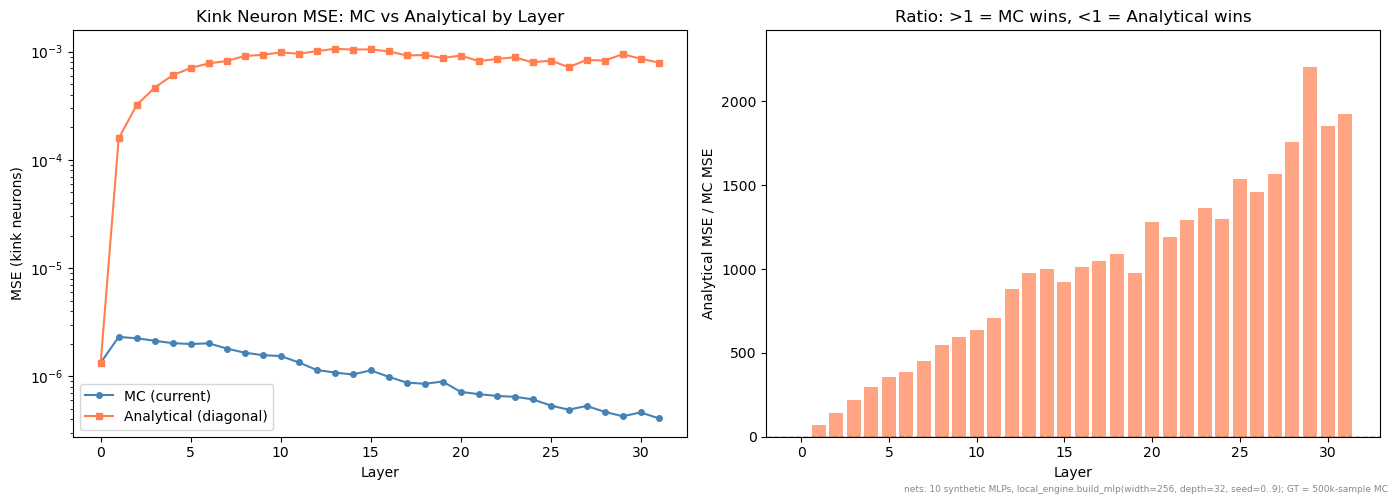

Layer 1: MC wins (ratio=68.3x worse)Layer 2: MC wins (ratio=142.9x worse)Layer 3: MC wins (ratio=217.8x worse)Layer 4: MC wins (ratio=298.6x worse)Layer 5: MC wins (ratio=354.2x worse)Layer 6: MC wins (ratio=385.3x worse)Layer 7: MC wins (ratio=452.4x worse)Layer 8: MC wins (ratio=550.1x worse)Layer 9: MC wins (ratio=594.4x worse)Layer 10: MC wins (ratio=638.4x worse)Layer 11: MC wins (ratio=709.9x worse)Layer 12: MC wins (ratio=879.9x worse)Layer 13: MC wins (ratio=978.1x worse)Layer 14: MC wins (ratio=1002.5x worse)Layer 15: MC wins (ratio=923.0x worse)Layer 16: MC wins (ratio=1013.9x worse)Layer 17: MC wins (ratio=1050.8x worse)Layer 18: MC wins (ratio=1088.0x worse)Layer 19: MC wins (ratio=974.4x worse)Layer 20: MC wins (ratio=1278.1x worse)Layer 21: MC wins (ratio=1191.7x worse)Layer 22: MC wins (ratio=1295.6x worse)Layer 23: MC wins (ratio=1367.3x worse)Layer 24: MC wins (ratio=1296.0x worse)Layer 25: MC wins (ratio=1535.3x worse)Layer 26: MC wins (ratio=1460.4x worse)Layer 27: M

In [20]:
# Per-layer breakdown: where does analytical beat MC?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mse_mc_by_layer = []
mse_an_by_layer = []
for layer in range(DEPTH):
    kink_l = all_types[:, layer, :] == 1
    if kink_l.sum() > 0:
        mse_mc_by_layer.append(np.mean(errors[:, layer, :][kink_l]**2))
        mse_an_by_layer.append(np.mean(errors_analytical[:, layer, :][kink_l]**2))
    else:
        mse_mc_by_layer.append(0)
        mse_an_by_layer.append(0)

ax = axes[0]
ax.plot(range(DEPTH), mse_mc_by_layer, 'o-', label='MC (current)', color='steelblue', markersize=4)
ax.plot(range(DEPTH), mse_an_by_layer, 's-', label='Analytical (diagonal)', color='coral', markersize=4)
ax.set_xlabel('Layer')
ax.set_ylabel('MSE (kink neurons)')
ax.set_title('Kink Neuron MSE: MC vs Analytical by Layer')
ax.set_yscale('log')
ax.legend()

# Ratio
ax = axes[1]
ratio = np.array(mse_an_by_layer) / (np.array(mse_mc_by_layer) + 1e-20)
ax.bar(range(DEPTH), ratio, color=['coral' if r > 1 else 'seagreen' for r in ratio], alpha=0.7)
ax.axhline(1, color='k', lw=1, ls='--')
ax.set_xlabel('Layer')
ax.set_ylabel('Analytical MSE / MC MSE')
ax.set_title('Ratio: >1 = MC wins, <1 = Analytical wins')
ax.set_ylim(0, max(ratio) * 1.1)

plt.tight_layout()
plt.show()

# Find the crossover point
for i, (mc, an) in enumerate(zip(mse_mc_by_layer, mse_an_by_layer)):
    if an < mc and mc > 0:
        print(f"Layer {i}: Analytical WINS (MSE {an:.2e} < {mc:.2e}, ratio={an/mc:.2f})")
    elif mc > 0:
        print(f"Layer {i}: MC wins (ratio={an/mc:.1f}x worse)" if an/mc > 2 else "", end="")

In [21]:
# Break down by α value: are near-dead kinks (α ≈ -2.5) different from central kinks (α ≈ 0)?
# The analytical formula should be MORE accurate for extreme α (near-dead or near-on)
# and LESS accurate for α ≈ 0 (where the sigmoid transition is steepest).

kink_alphas = all_alphas[kink_mask_all]
kink_mc_err = errors[kink_mask_all]
kink_an_err = errors_analytical[kink_mask_all]

# Bin by |α|
alpha_bins = [(-3.0, -2.0), (-2.0, -1.0), (-1.0, 0.0), (0.0, 1.0), (1.0, 2.0), (2.0, 2.5)]

print(f"{'α range':<12} | {'n':>6} | {'MC MSE':>10} | {'Anal MSE':>10} | {'Ratio (A/MC)':>12} | {'Anal better?':>12}")
print("-" * 80)

bin_centers_plot = []
ratios_plot = []
mc_mses_plot = []
an_mses_plot = []

for lo, hi in alpha_bins:
    mask = (kink_alphas >= lo) & (kink_alphas < hi)
    n = mask.sum()
    if n < 10:
        continue
    mse_mc_bin = np.mean(kink_mc_err[mask]**2)
    mse_an_bin = np.mean(kink_an_err[mask]**2)
    ratio_bin = mse_an_bin / mse_mc_bin
    better = "YES ✓" if ratio_bin < 1 else "no"
    print(f"[{lo:+.1f}, {hi:+.1f}) | {n:>6} | {mse_mc_bin:>10.2e} | {mse_an_bin:>10.2e} | {ratio_bin:>12.1f}x | {better:>12}")
    bin_centers_plot.append((lo + hi) / 2)
    ratios_plot.append(ratio_bin)
    mc_mses_plot.append(mse_mc_bin)
    an_mses_plot.append(mse_an_bin)

# Also check: does layer matter within each α bin?
print("\n\n--- Layer × α interaction (is analytical ever useful?) ---")
print(f"{'Layer':<6} {'α ∈ [-3,-2)':<12} {'α ∈ [-1,0)':<12} {'α ∈ [0,1)':<12} {'α ∈ [1,2.5)':<12}")
print("-" * 55)

for layer in [0, 5, 10, 15, 20, 25, 30, 31]:
    row_str = f"{layer:<6}"
    for (lo, hi) in [(-3.0, -2.0), (-1.0, 0.0), (0.0, 1.0), (1.0, 2.5)]:
        mask_l = (all_types[:, layer, :] == 1)
        alpha_l = all_alphas[:, layer, :]
        combined = mask_l & (alpha_l >= lo) & (alpha_l < hi)
        n = combined.sum()
        if n < 5:
            row_str += f"{'n/a':<12}"
            continue
        mc_mse_l = np.mean(errors[:, layer, :][combined]**2)
        an_mse_l = np.mean(errors_analytical[:, layer, :][combined]**2)
        ratio_l = an_mse_l / mc_mse_l
        row_str += f"{ratio_l:>6.0f}x     "
    print(row_str)

α range      |      n |     MC MSE |   Anal MSE | Ratio (A/MC) | Anal better?
--------------------------------------------------------------------------------
[-3.0, -2.0) |   3133 |   1.45e-08 |   5.61e-06 |        387.6x |           no
[-2.0, -1.0) |   8190 |   1.27e-07 |   8.17e-05 |        644.9x |           no
[-1.0, +0.0) |  10922 |   7.80e-07 |   5.40e-04 |        692.7x |           no
[+0.0, +1.0) |  13446 |   1.85e-06 |   8.54e-04 |        461.7x |           no
[+1.0, +2.0) |   8240 |   2.59e-06 |   1.38e-03 |        532.5x |           no
[+2.0, +2.5) |   3196 |   2.66e-06 |   1.69e-03 |        635.4x |           no


--- Layer × α interaction (is analytical ever useful?) ---
Layer  α ∈ [-3,-2)  α ∈ [-1,0)   α ∈ [0,1)    α ∈ [1,2.5) 
-------------------------------------------------------
0     n/a         n/a              1x     n/a         
5        190x        489x        396x        282x     
10       612x       1072x        701x        529x     
15       918x       1750x 

## 15. Always-On Bias Check (Current Estimator: N=40960 + Dead Correction)

Re-run the estimator with the current settings and check if always-on neurons
still show systematic underestimation.

In [22]:
# Re-run current estimator (N=40960 + dead correction + α<-3.0) on 10 MLPs
# Era repoint (2026-07-25): repo-root estimator.py is now the 318873 submission; load the
# #13-era root estimator (N=40960 + dead correction) preserved from git ea49268 instead.
_specE = _ilu.spec_from_file_location("era13_root_estimator", str(HIST / "estimator_ea49268_era13.py"))
est_mod = _ilu.module_from_spec(_specE); _specE.loader.exec_module(est_mod)

N_MLPS_NEW = 10
predictions_new = []
ground_truths_new = []

for seed in range(N_MLPS_NEW):
    mlp = build_mlp(width=WIDTH, depth=DEPTH, seed=seed)
    
    # Ground truth: 500k MC
    with flops.BudgetContext(flop_budget=int(1e13), quiet=True):
        gt = monte_carlo_layer_means(mlp, 500_000, seed=seed + 2000)
    
    # Current estimator
    est = est_mod.Estimator()
    with flops.BudgetContext(flop_budget=272_000_000_000, quiet=True) as ctx:
        pred = est.predict(mlp, 272_000_000_000)
    
    predictions_new.append(np.asarray(pred))
    ground_truths_new.append(np.asarray(gt))

predictions_new = np.array(predictions_new)
ground_truths_new = np.array(ground_truths_new)
errors_new = predictions_new - ground_truths_new

print(f"Current estimator: N={est_mod._MAIN_SAMPLES}, FLOPs={ctx.flops_used:,.0f}")
print(f"Overall MSE: {np.mean(errors_new**2):.3e}")
print(f"Overall bias: {np.mean(errors_new):.3e}")

# Reclassify with new threshold
DEAD_THRESH_NEW = -3.0
all_types_new = np.zeros((N_MLPS_NEW, DEPTH, WIDTH), dtype=int)
all_alphas_new = np.zeros((N_MLPS_NEW, DEPTH, WIDTH))

for mlp_idx in range(N_MLPS_NEW):
    mu_post = np.zeros(WIDTH)
    var_post = np.zeros(WIDTH)
    mlp = build_mlp(width=WIDTH, depth=DEPTH, seed=mlp_idx)
    for layer_idx in range(DEPTH):
        w = np.asarray(mlp.weights[layer_idx])
        if layer_idx == 0:
            mu_pre = np.zeros(WIDTH)
            var_pre = np.sum(w * w, axis=0)
        else:
            mu_pre = w.T @ mu_post
            var_pre = np.sum(w * w * var_post[:, None], axis=0)
        var_pre = np.maximum(var_pre, 1e-12)
        sigma_pre = np.sqrt(var_pre)
        alpha = mu_pre / sigma_pre
        
        types = np.ones(WIDTH, dtype=int)  # kink
        types[alpha < DEAD_THRESH_NEW] = 0  # dead
        types[alpha > ON_THRESH] = 2        # on
        all_types_new[mlp_idx, layer_idx, :] = types
        all_alphas_new[mlp_idx, layer_idx, :] = alpha
        
        from scipy.stats import norm
        phi = norm.pdf(alpha)
        Phi = norm.cdf(alpha)
        mu_post = mu_pre * Phi + sigma_pre * phi
        var_post = (var_pre + mu_pre**2) * Phi + mu_pre * sigma_pre * phi - mu_post**2
        var_post = np.maximum(var_post, 1e-12)

# Always-on analysis
on_mask_new = all_types_new == 2
kink_mask_new = all_types_new == 1
dead_mask_new = all_types_new == 0

print(f"\n=== Always-On Neuron Bias (current estimator) ===")
print(f"Type distribution: dead={dead_mask_new.mean()*100:.1f}%, kink={kink_mask_new.mean()*100:.1f}%, on={on_mask_new.mean()*100:.1f}%")
print(f"\nBy type:")
for t, name in enumerate(['Dead', 'Kink', 'Always-On']):
    mask = all_types_new == t
    if mask.sum() > 0:
        t_err = errors_new[mask]
        frac_under = np.mean(t_err < 0) * 100
        print(f"  {name:10s}: MSE={np.mean(t_err**2):.3e}, bias={np.mean(t_err):+.3e}, "
              f"under={frac_under:.0f}%, n={mask.sum()}")

# Per-layer bias for always-on
print(f"\nAlways-On bias by layer:")
print(f"{'Layer':<6} {'Bias':>12} {'MSE':>12} {'%Under':>8} {'n':>6}")
for layer in range(DEPTH):
    on_l = all_types_new[:, layer, :] == 2
    if on_l.sum() > 10:
        on_err = errors_new[:, layer, :][on_l]
        print(f"{layer:<6} {np.mean(on_err):>+12.3e} {np.mean(on_err**2):>12.3e} "
              f"{np.mean(on_err < 0)*100:>7.0f}% {on_l.sum():>6}")

/Users/natashastewart/whest-kprop-experiments/.nb_history_bytes/estimator_ea49268_era13.py:26: SymmetryLossWarning: Symmetry lost along dims (0, 1): slicing removed all symmetric dim groups. Use as_symmetric() to re-tag if you know the result is symmetric. Suppress with flops.configure(symmetry_warnings=False).
  scatter_mat = fnp.eye(width, dtype=fnp.float32)[:, idx]  # (width, k) — READ indexing


Current estimator: N=40960, FLOPs=120,564,918,024
Overall MSE: 1.758e-06
Overall bias: 3.115e-05



=== Always-On Neuron Bias (current estimator) ===
Type distribution: dead=17.9%, kink=60.8%, on=21.4%

By type:
  Dead      : MSE=1.599e-08, bias=-1.043e-05, under=19%, n=14624
  Kink      : MSE=1.570e-06, bias=+2.672e-05, under=50%, n=49794
  Always-On : MSE=3.750e-06, bias=+7.849e-05, under=50%, n=17502

Always-On bias by layer:
Layer          Bias          MSE   %Under      n
2        +7.768e-06    5.995e-06      50%     12
3        -3.123e-05    5.856e-06      51%     61
4        +1.626e-04    5.290e-06      46%    152
5        +5.277e-04    6.063e-06      40%    219
6        +2.662e-04    5.449e-06      49%    270
7        +2.485e-04    5.573e-06      46%    315
8        +2.072e-04    5.851e-06      49%    380
9        +3.290e-04    5.851e-06      48%    397
10       +2.503e-04    5.110e-06      47%    443
11       +9.129e-05    5.205e-06      50%    479
12       +6.563e-05    4.728e-06      50%    535
13       +1.808e-04    4.702e-06      47%    551
14       +3.810e-05    4.429e